In [ ]:
pip install tensorflow


In [ ]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [ ]:
pip install tensorflow matplotlib scikit-learn

In [ ]:
import tensorflow as tf, numpy as np, time
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
print(tf.__version__, tf.config.list_physical_devices('GPU'))

2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#step-2-load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(label_mode="fine")
print(x_train.shape, y_train.shape, x_test.shape)   # (50000,32,32,3) (50000,1) (10000,32,32,3)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 71s 0us/step
(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3)


In [ ]:
#step-3-Preprocess and split
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

mean = x_train.mean(axis=(0,1,2)); std = x_train.std(axis=(0,1,2))
x_train = (x_train - mean) / std
x_test  = (x_test - mean) / std

# hold out 5,000 for validation
x_val, y_val = x_train[45000:], y_train[45000:]
x_train, y_train = x_train[:45000], y_train[:45000]
print(x_train.shape, x_val.shape, x_test.shape)

(45000, 32, 32, 3) (5000, 32, 32, 3) (10000, 32, 32, 3)


In [ ]:
#step-4-tf.data pipeline
BS = 128
aug = tf.keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomTranslation(0.1, 0.1)])

train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .shuffle(10000).batch(BS)
            .map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))
val_ds  = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BS)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BS)

In [ ]:
BS = 128
train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .shuffle(10000).batch(BS).prefetch(tf.data.AUTOTUNE))
val_ds  = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BS)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BS)


In [ ]:
#Build the model (Step 5)
def block(f):
    return [layers.Conv2D(f, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
            layers.Conv2D(f, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
            layers.MaxPooling2D(), layers.Dropout(0.25)]

model = models.Sequential(
    [layers.Input((32, 32, 3))] + block(64) + block(128) + block(256) +
    [layers.Flatten(), layers.Dense(512, activation="relu"),
     layers.Dropout(0.5), layers.Dense(100)]
)
model.summary()
print("Parameters:", model.count_params())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 256)      │             

 Total params: 3,297,956 (12.58 MB)

 Trainable params: 3,296,164 (12.57 MB)

 Non-trainable params: 1,792 (7.00 KB)

Parameters: 3297956


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(5, name="top5")]
)
t0 = time.time()
hist = model.fit(train_ds, validation_data=val_ds, epochs=3)
train_time = time.time() - t0
print("Total:", train_time, "| per epoch:", train_time / 3)

Epoch 1/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 36s 63ms/step - accuracy: 0.0218 - loss: 4.5179 - top5: 0.0985 - val_accuracy: 0.0360 - val_loss: 4.4131 - val_top5: 0.1432
Epoch 2/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.0327 - loss: 4.3060 - top5: 0.1380 - val_accuracy: 0.0562 - val_loss: 4.1047 - val_top5: 0.2194
Epoch 3/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.0361 - loss: 4.2433 - top5: 0.1510 - val_accuracy: 0.0688 - val_loss: 4.0348 - val_top5: 0.2412
Total: 58.96830439567566 | per epoch: 19.65610146522522


In [ ]:
#Train (Step 6)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(5, name="top5")]
)
t0 = time.time()
hist = model.fit(train_ds, validation_data=val_ds, epochs=30,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
               tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)])
train_time = time.time() - t0
print("Total:", train_time, "| per epoch:", train_time / len(hist.history["loss"]))

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.0386 - loss: 4.2248 - top5: 0.1589 - val_accuracy: 0.0782 - val_loss: 3.9485 - val_top5: 0.2854 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.0416 - loss: 4.1628 - top5: 0.1716 - val_accuracy: 0.0922 - val_loss: 3.9178 - val_top5: 0.3104 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.0435 - loss: 4.1249 - top5: 0.1766 - val_accuracy: 0.0898 - val_loss: 3.8312 - val_top5: 0.3090 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.0454 - loss: 4.0764 - top5: 0.1875 - val_accuracy: 0.0960 - val_loss: 3.8091 - val_top5: 0.3424 - learning_rate: 0.0010
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.0537 - loss: 4.0150 - top5: 0.2021 - val_accuracy: 0.0942 - val_loss: 3.8087 - val_top5: 0.3160 - learning_rate: 0.0010
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accu

In [ ]:
#Evaluate on the test set(step-7)
test_loss, test_acc, test_top5 = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f} | Top-5: {test_top5:.4f}")
print(f"Final train acc: {hist.history['accuracy'][-1]:.4f} | Final val acc: {hist.history['val_accuracy'][-1]:.4f}")
print(f"Best val acc: {max(hist.history['val_accuracy']):.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5290 - loss: 1.7398 - top5: 0.8204
Test loss: 1.7398 | Test acc: 0.5290 | Top-5: 0.8204
Final train acc: 0.5498 | Final val acc: 0.5262
Best val acc: 0.5262


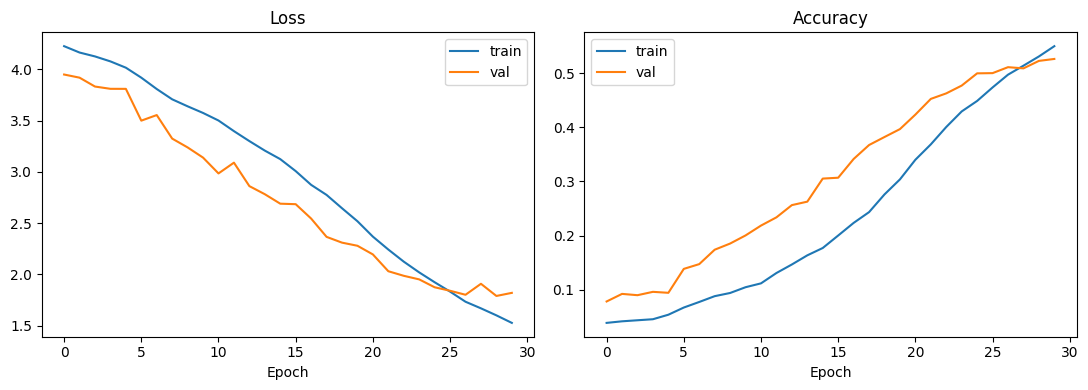

In [ ]:
#Plot the curves(step-8)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist.history["loss"], label="train"); ax[0].plot(hist.history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(hist.history["accuracy"], label="train"); ax[1].plot(hist.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


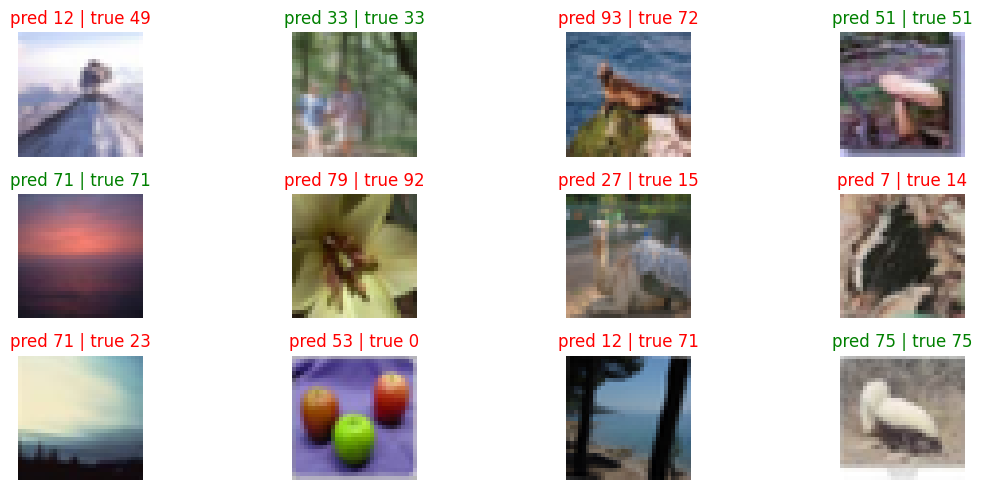

In [ ]:
#predictions
from tensorflow.keras.datasets import cifar100
(_, _), (x_raw, y_raw) = cifar100.load_data(label_mode="fine")
probs = model.predict(x_test[:12])
preds = probs.argmax(axis=1)
plt.figure(figsize=(12, 5))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_raw[i]); plt.axis("off")
    plt.title(f"pred {preds[i]} | true {y_raw[i][0]}", color="green" if preds[i] == y_raw[i][0] else "red")
plt.tight_layout(); plt.show()

In [ ]:
# Reload data with the same normalization as PyTorch: (x/255 - 0.5) / 0.5
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.cifar100.load_data(label_mode="fine")
x_tr = (x_tr.astype("float32") / 255.0 - 0.5) / 0.5
x_te = (x_te.astype("float32") / 255.0 - 0.5) / 0.5

BS = 32
tr_ds = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).shuffle(10000).batch(BS).prefetch(tf.data.AUTOTUNE)
te_ds = tf.data.Dataset.from_tensor_slices((x_te, y_te)).batch(BS)

# Same architecture as SimpleCNN
m2 = models.Sequential([
    layers.Input((32, 32, 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"), layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(100),
])
print("Parameters:", m2.count_params())   # should be 1,093,924, same as PyTorch

m2.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
           loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
           metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(5, name="top5")])

t0 = time.time()
h2 = m2.fit(tr_ds, validation_data=te_ds, epochs=30)
t2 = time.time() - t0
print("Total:", t2, "| per epoch:", t2 / 30)

loss2, acc2, top5_2 = m2.evaluate(te_ds)
print(f"Test acc: {acc2:.4f} | Top-5: {top5_2:.4f} | Test loss: {loss2:.4f}")

Parameters: 1093924
Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.1226 - loss: 3.8853 - top5: 0.3163 - val_accuracy: 0.1838 - val_loss: 3.5200 - val_top5: 0.4213
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2188 - loss: 3.3236 - top5: 0.4760 - val_accuracy: 0.2356 - val_loss: 3.2402 - val_top5: 0.5017
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2676 - loss: 3.0646 - top5: 0.5446 - val_accuracy: 0.2725 - val_loss: 3.0704 - val_top5: 0.5446
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3073 - loss: 2.8575 - top5: 0.5940 - val_accuracy: 0.2933 - val_loss: 2.9417 - val_top5: 0.5736
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3442 - loss: 2.6870 - top5: 0.6321 - val_accuracy: 0.3164 - val_loss: 2.8454 - val_top5: 0.5992
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3740 - loss: 2.5423 - top5: 0.6618 - val_accuracy: 0.3355 - val_loss: 2.7384 - val_top5: 0